In [ ]:
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader
import numpy as np
from fairchem.core.datasets import AseDBDataset
from torch.nn import Linear
from torch_geometric.nn import SchNet
from torch_geometric.data import Data
from torch_cluster import radius_graph
import matplotlib.pyplot as plt
from read_multi_ase import *
from extract_normalize import *

In [2]:
#Determine the device to be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SchNetModel(torch.nn.Module):
    def __init__(self,
                 hidden_channels: int = 128,
                 num_filters: int = 128,
                 num_interactions: int = 6,
                 num_gaussians: int = 50,
                 cutoff: int = 5,
                 max_num_neighbors: int = 32,
                 readout: str = "add",
                 dipole: bool = False,
                 mean: float = None,
                 std: float = None,
                 atomref: torch.Tensor = None,
                 train_mean: float = None,
                 train_std: float = None):
        super().__init__()

        #Create SchNet module with parameters
        self.schnet = SchNet(
            hidden_channels = hidden_channels,
            num_filters = num_filters,
            num_interactions = num_interactions,
            num_gaussians = num_gaussians,
            cutoff = cutoff,
            max_num_neighbors = max_num_neighbors,
            readout = readout,
            dipole = dipole,
            mean = mean,
            std = std,
            atomref = atomref)

        #Keep track of training mean and std for normalization function
        self.mean = train_mean
        self.std = train_std

    #Forward step for model
    def forward(self, data):
        out = self.schnet(data.z, data.pos, batch=data.batch)
        return out


def train(model: SchNetModel, train_data: list):
    model.train()
    #Keep track of total loss for all data
    total_train_loss = 0

    for data in train_data:
        data = data.to(device)

        #Reset optimizers
        optimizer.zero_grad()

        #Forward step internally performed by PyTorch to obtain predictions (Same as model.forward(data))
        y_pred = model(data)
        y_target = data.y.unsqueeze(-1)

        #Determine train loss based on loss function with predictions and targets
        train_loss = loss_function(y_pred, y_target)

        #Backward step to calculate gradients
        train_loss.backward()
        #Updated optimizers
        optimizer.step()

        #Add train loss of current data to total train loss
        total_train_loss += train_loss.item()

    return total_train_loss / len(train_data)

@torch.no_grad()
def evaluate(model: SchNetModel, val_data: list):
    model.eval()
    total_val_loss = 0

    for data in val_data:
        data = data.to(device)

        #Forward step internally performed by PyTorch to obtain predictions (Same as model.forward(data))
        y_pred = model(data)
        y_target = data.y.unsqueeze(-1)

        #Determine validation loss based on loss function with predictions and targets
        val_loss = loss_function(y_pred, y_target)

        #Add validation loss of current data to total validation loss
        total_val_loss += val_loss.item()

    return total_val_loss / len(val_data)

@torch.no_grad()
def test(model: SchNetModel, test_data: list):
    model.eval()

    total_mae = 0
    total_mse = 0
    n_molecules = 0

    for data in test_data:
        data = data.to(device)

        y_pred = model(data)
        y_target = data.y.unsqueeze(-1)


        y_pred = y_pred * model.std + model.mean
        y_target = y_target * model.std + model.mean


        mae = torch.abs(y_pred - y_target).sum()
        mse = ((y_pred - y_target) ** 2).sum()

        total_mae += mae.item()
        total_mse += mse.item()
        n_molecules += y_target.size(0)

    mean_mae = total_mae / n_molecules
    rmse = (total_mse / n_molecules) ** 0.5

    return mean_mae, rmse

## SchNet (Cutoff = 5, readout = add, 1000 molecules, 100 epochs, lr = 1e-4)

In [ ]:
#Initialize model with desired parameters
bio_model = SchNetModel(cutoff = 5, readout = "add").to(device)
#Create ADAM optimizer based on model's parameters and desired learning rate
optimizer = torch.optim.Adam(bio_model.parameters(), lr=1e-4)
#Select loss function for model
loss_function = torch.nn.SmoothL1Loss()

In [141]:
dataset_path = "./train_4M/data0000.aselmdb"
dataset = AseDBDataset({"src": dataset_path})

In [142]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 1000)
bio_data = get_data(bio_sample)
bio_train, bio_val = split_data(bio_data, 0.8)

Processed 1000 atoms


In [143]:
bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
print(bio_model.mean, bio_model.std)

8.304791324213147 1.8713732864946322


In [144]:
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)

In [145]:
bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)

In [146]:
epochs = 100
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

/opt/miniconda3/envs/277b-final/lib/python3.11/site-packages/torch/nn/modules/loss.py:1052: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)


Epoch 001 | Train Loss: 4.8597 | Val Loss: 1.4102
Epoch 006 | Train Loss: 0.7158 | Val Loss: 0.7322
Epoch 011 | Train Loss: 0.5067 | Val Loss: 0.5521
Epoch 016 | Train Loss: 0.4948 | Val Loss: 0.5164
Epoch 021 | Train Loss: 0.8525 | Val Loss: 0.5376
Epoch 026 | Train Loss: 0.6159 | Val Loss: 0.4844
Epoch 031 | Train Loss: 0.4980 | Val Loss: 0.4824
Epoch 036 | Train Loss: 0.8208 | Val Loss: 0.6041
Epoch 041 | Train Loss: 0.4737 | Val Loss: 0.5803
Epoch 046 | Train Loss: 0.4648 | Val Loss: 0.5723
Epoch 051 | Train Loss: 0.4847 | Val Loss: 0.5344
Epoch 056 | Train Loss: 0.4562 | Val Loss: 0.6048
Epoch 061 | Train Loss: 0.5004 | Val Loss: 0.4921
Epoch 066 | Train Loss: 0.5128 | Val Loss: 0.4640
Epoch 071 | Train Loss: 0.4694 | Val Loss: 0.4563
Epoch 076 | Train Loss: 0.4753 | Val Loss: 0.6284
Epoch 081 | Train Loss: 0.5684 | Val Loss: 0.4923
Epoch 086 | Train Loss: 0.6555 | Val Loss: 0.4857
Epoch 091 | Train Loss: 0.5589 | Val Loss: 0.4477
Epoch 096 | Train Loss: 0.4304 | Val Loss: 0.4875


In [18]:
def plot_losses(train_loss, val_loss):
    """Plot training vs validation loss from a history dict."""
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss, label='Train Loss', linewidth=2)
    plt.plot(val_loss, label='Validation Loss',
             linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('SchNet Model Training vs Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

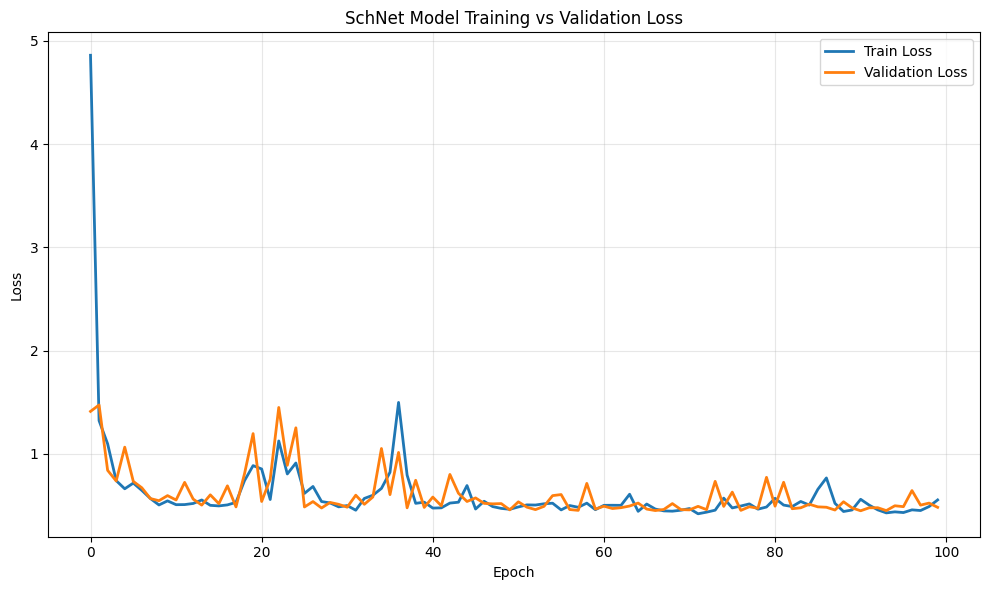

In [148]:
plot_losses(bio_train_losses, bio_val_losses)

In [149]:
bio_testing = process_file(file="./train_4M/data0001.aselmdb", molecule_type= "biomolecules", max_molecules= 200)
bio_test = get_data(bio_testing)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_test_loader = DataLoader(bio_test, batch_size=32)

mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Processed 200 atoms
tensor([[8.2820],
        [8.5652],
        [8.8720],
        [7.1605],
        [7.6788],
        [8.2396],
        [8.9658],
        [8.6347],
        [8.5839],
        [8.3302],
        [9.3426],
        [8.0048],
        [8.4631],
        [8.3230],
        [8.5519],
        [8.3816],
        [8.4263],
        [8.4858],
        [8.1871],
        [8.7208],
        [8.3219],
        [8.1465],
        [9.0595],
        [9.6101],
        [8.1032],
        [8.1345],
        [8.4195],
        [8.6193],
        [8.1244],
        [7.7724],
        [8.5469],
        [8.7110]])
tensor([[ 8.5641],
        [ 8.5310],
        [ 7.6562],
        [ 6.0228],
        [ 8.9376],
        [ 9.4070],
        [ 8.0304],
        [ 8.6578],
        [10.7479],
        [ 9.2960],
        [ 7.3310],
        [ 8.1302],
        [ 9.2981],
        [ 4.5747],
        [ 7.4017],
        [ 6.2372],
        [ 8.0214],
        [ 6.3542],
        [ 6.2606],
        [ 9.0382],
        [11.2337],
    

## SchNet (Cutoff = 5, readout = add, 1000 molecules, 100 epochs, lr = 5e-5)

In [ ]:
#Initialize model with desired parameters
bio_model = SchNetModel(cutoff = 5, readout = "add").to(device)
#Create ADAM optimizer based on model's parameters and desired learning rate
optimizer = torch.optim.Adam(bio_model.parameters(), lr=5e-5)
#Select loss function for model
loss_function = torch.nn.SmoothL1Loss()

In [150]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 1000)
bio_data = get_data(bio_sample)
bio_train, bio_val = split_data(bio_data, 0.8)

Processed 1000 atoms


In [152]:
bio_model.mean, bio_model.std = obtain_mean_std(bio_train)

In [153]:
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)

In [154]:
obtain_mean_std(bio_train)

(3.7237623473629357e-09, 0.9999999998190197)

In [155]:
bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)

In [156]:
epochs = 100
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

/opt/miniconda3/envs/277b-final/lib/python3.11/site-packages/torch/nn/modules/loss.py:1052: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)
/opt/miniconda3/envs/277b-final/lib/python3.11/site-packages/torch/nn/modules/loss.py:1052: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)


Epoch 001 | Train Loss: 8.6549 | Val Loss: 1.7414
Epoch 006 | Train Loss: 0.6854 | Val Loss: 0.7460
Epoch 011 | Train Loss: 0.5421 | Val Loss: 0.4349
Epoch 016 | Train Loss: 0.6343 | Val Loss: 0.4701
Epoch 021 | Train Loss: 0.5172 | Val Loss: 0.5158
Epoch 026 | Train Loss: 0.6123 | Val Loss: 0.5403
Epoch 031 | Train Loss: 0.5325 | Val Loss: 0.6199
Epoch 036 | Train Loss: 0.4561 | Val Loss: 0.3958
Epoch 041 | Train Loss: 0.5056 | Val Loss: 0.6012
Epoch 046 | Train Loss: 0.4523 | Val Loss: 0.3708
Epoch 051 | Train Loss: 0.4531 | Val Loss: 0.7341
Epoch 056 | Train Loss: 0.4489 | Val Loss: 0.3599
Epoch 061 | Train Loss: 0.4211 | Val Loss: 0.3608
Epoch 066 | Train Loss: 0.4532 | Val Loss: 0.4263
Epoch 071 | Train Loss: 0.4713 | Val Loss: 0.4746
Epoch 076 | Train Loss: 0.4816 | Val Loss: 0.3569
Epoch 081 | Train Loss: 0.4696 | Val Loss: 0.3553
Epoch 086 | Train Loss: 0.6328 | Val Loss: 0.5609
Epoch 091 | Train Loss: 0.4411 | Val Loss: 0.3903
Epoch 096 | Train Loss: 0.4399 | Val Loss: 0.4612


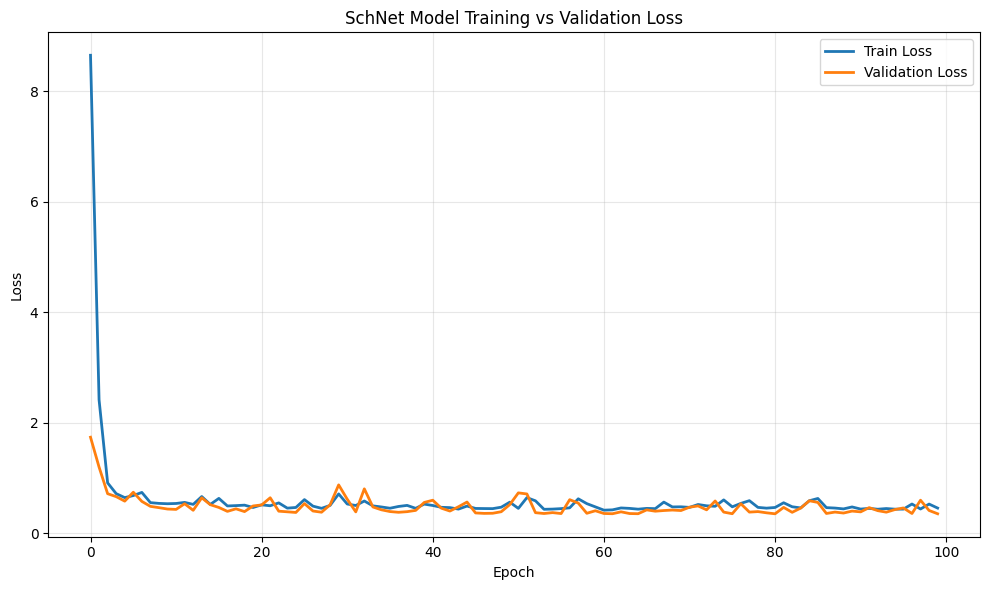

In [157]:
plot_losses(bio_train_losses, bio_val_losses)

In [ ]:
bio_testing = process_file(file="./train_4M/data0001.aselmdb", molecule_type= "biomolecules", max_molecules= 200)
bio_test = get_data(bio_testing)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_test_loader = DataLoader(bio_test, batch_size=32)

mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Processed 200 atoms
Test MAE:  1.5297
Test RMSE: 1.9926


## SchNet normalized with lr 1e-4

In [13]:
#Initialize model with desired parameters
bio_model = SchNetModel(readout = "mean").to(device)
#Create ADAM optimizer based on model's parameters and desired learning rate
optimizer = torch.optim.Adam(bio_model.parameters(), lr=1e-4)
#Select loss function for model
loss_function = torch.nn.SmoothL1Loss()

In [14]:
bio_sample = process_file(file= "../../train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 1000)
# bio_sample = process_file(file= ["./train_4M/data0000.aselmdb", "./train_4M/data0001.aselmdb"], molecule_type= "biomolecules", max_molecules = 1000)
bio_data = get_data(bio_sample)
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

Processed 1000 atoms


In [15]:
bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

In [16]:
bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

In [17]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 0.3606 | Val Loss: 0.3323
Epoch 006 | Train Loss: 0.3070 | Val Loss: 0.2988
Epoch 011 | Train Loss: 0.2989 | Val Loss: 0.2897
Epoch 016 | Train Loss: 0.2971 | Val Loss: 0.2863
Epoch 021 | Train Loss: 0.2845 | Val Loss: 0.2825
Epoch 026 | Train Loss: 0.2750 | Val Loss: 0.2802
Epoch 031 | Train Loss: 0.2729 | Val Loss: 0.2803
Epoch 036 | Train Loss: 0.2612 | Val Loss: 0.2811
Epoch 041 | Train Loss: 0.2606 | Val Loss: 0.2842
Epoch 046 | Train Loss: 0.2474 | Val Loss: 0.2810


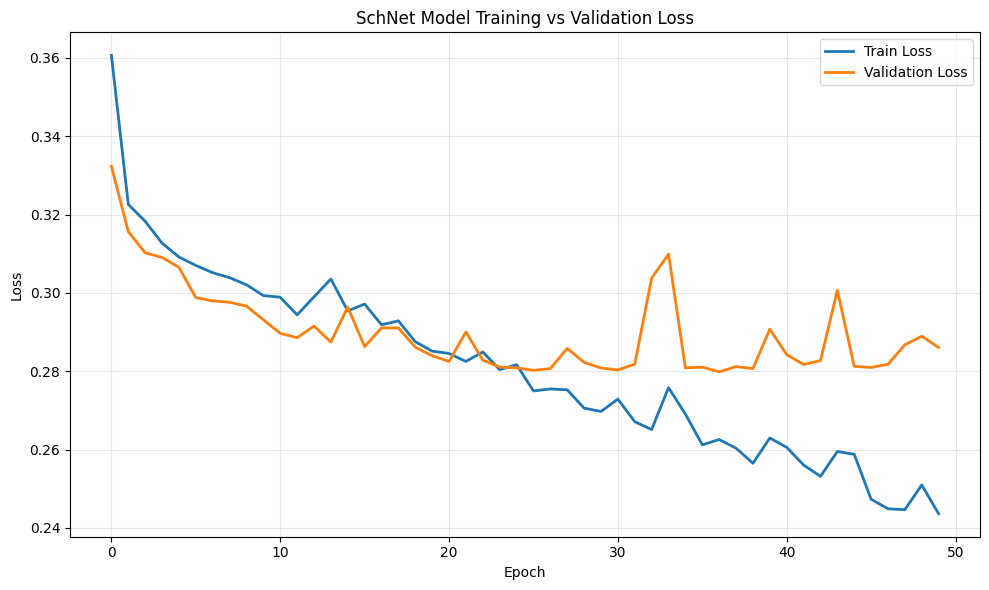

In [19]:
plot_losses(bio_train_losses, bio_val_losses)

In [20]:
mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  1.0820
Test RMSE: 1.5240
